In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import gzip

In [2]:

excluded_samples = ['ST002-1D_LUNG-pacbio-uwsc-group1']

In [3]:

df_pb = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/qc_summary.tsv", sep='\t')
df_pb[['Donor', 'Tissue', 'Seq_Tech', 'Center', 'Group']] = df_pb['Sample'].str.split('-', expand=True)
#df_pb = df_pb.sort_values(['Donor', 'Tissue', 'Center'])
df_pb['Age'] = np.where(df_pb['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df_ont = pd.read_csv("/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/qc_summary.tsv", sep='\t')
df_ont[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = df_ont['Sample'].str.split('-', expand=True)
#df_ont = df_ont.sort_values(['Donor', 'Tissue', 'Center'])
df_ont['Age'] = np.where(df_ont['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')

df = pd.concat([df_pb, df_ont]).reset_index()
df['Donor_Tissue'] = df['Donor'] + "-" + df['Tissue']
df = df.sort_values(['Tissue', 'Donor', 'Center'])

df = df[~(df['Sample'].isin(excluded_samples))]

df['mtDNA_CN_norm'] = df['mtDNA_CN'] / df['Nuclear_Coverage']
df['Tissue'] = df['Tissue'].str.split('_', expand=True)[1].str.capitalize()

df

,index,Sample,Total_Read_Count,ChrM_Read_Count,Kmer_Read_Count,Mito_Read_Count,mtDNA_CN,Mean_Read_Length,Median_Read_Length,Mito_Coverage,Nuclear_Coverage,Haplogroup,Donor,Tissue,Seq_Tech,Center,Group,Age,Donor_Tissue,mtDNA_CN_norm
11,11,ST001-1A_LIVER-pacbio-bcm,14733673,14030,13923,13882,11799.70,14196.79,14864.0,11884.93,72.80,H3b1b1,ST001,Liver,pacbio,bcm,None,Young,ST001-1A_LIVER,162.083791
39,17,ST001-1A_LIVER-ont-bcm,21967786,87222,58490,54220,33616.40,10104.80,9916.0,32778.45,78.40,H3b1b1,ST001,Liver,ont,bcm,NaN,Young,ST001-1A_LIVER,428.780612
14,14,ST001-1A_LIVER-pacbio-broad,12125667,26272,26232,26117,19848.92,12629.30,12192.0,19890.98,59.63,H3b1b1,ST001,Liver,pacbio,broad,None,Young,ST001-1A_LIVER,332.868019
36,14,ST001-1A_LIVER-ont-nygc,30322189,135334,45322,41247,16498.80,6593.18,5459.0,16250.77,80.87,H3b1b1,ST001,Liver,ont,nygc,NaN,Young,ST001-1A_LIVER,204.016322
15,15,ST001-1A_LIVER-pacbio-uwsc,4226911,15242,15188,15134,14528.64,15604.38,16404.0,14238.06,26.19,H3b1b1,ST001,Liver,pacbio,uwsc,None,Young,ST001-1A_LIVER,554.739977
38,16,ST001-1A_LIVER-ont-uwsc,78669019,579591,68136,48938,20553.96,6802.95,5441.0,19841.92,44.20,H3b1b1,ST001,Liver,ont,uwsc,NaN,Young,ST001-1A_LIVER,465.021719
16,16,ST001-1A_LIVER-pacbio-washu,11826270,19010,18961,18660,18473.40,16242.37,16555.0,18278.68,74.31,H3b1b1,ST001,Liver,pacbio,washu,None,Young,ST001-1A_LIVER,248.599112
1,1,ST001-1D_LUNG-pacbio-bcm,19895520,1248,1236,1232,1096.48,14310.17,14880.5,1062.95,97.95,H3b1b1,ST001,Lung,pacbio,bcm,None,Young,ST001-1D_LUNG,11.194283
25,3,ST001-1D_LUNG-ont-bcm,19937801,3449,2458,2265,1472.25,10924.42,10830.0,1479.81,87.54,H3b1b1,ST001,Lung,ont,bcm,NaN,Young,ST001-1D_LUNG,16.818026
6,6,ST001-1D_LUNG-pacbio-broad,15307052,1637,1636,1622,1297.60,13317.68,13431.5,1302.56,84.19,H3b1b1,ST001,Lung,pacbio,broad,None,Young,ST001-1D_LUNG,15.412757


In [4]:
comb_del_df = pd.DataFrame()

for sample in df_pb['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/pacbio/output/{sample}/variants/baldur/{sample}.mt.baldur_del.txt'
    del_df = pd.read_csv(file_path, sep='\t')
    del_df['Sample'] = sample
    comb_del_df = pd.concat([comb_del_df, del_df])

for sample in df_ont['Sample']:
    file_path = f'/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/benchmark/ont/output/{sample}/variants/baldur/{sample}.mt.baldur_del.txt'
    del_df = pd.read_csv(file_path, sep='\t')
    del_df['Sample'] = sample
    comb_del_df = pd.concat([comb_del_df, del_df])

comb_del_df = comb_del_df[comb_del_df['Type'] != 'Wildtype']
comb_del_df[['Start', 'End', 'Size', 'Fwd', 'Rev']] = comb_del_df[['Start', 'End', 'Size', 'Fwd', 'Rev']].astype(int)
comb_del_df['read_support'] = comb_del_df ['Fwd'] + comb_del_df ['Rev']
comb_del_df['Size'] = np.where(comb_del_df['Size'] < 0, -(comb_del_df['Size']), comb_del_df['Size'])

comb_del_df = pd.merge(comb_del_df, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
comb_del_df['per_mtdna'] = comb_del_df['read_support'] / comb_del_df['Mito_Read_Count']
comb_del_df[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = comb_del_df['Sample'].str.split('-', expand=True)
comb_del_df['Donor_Tissue'] = comb_del_df['Donor'] + "_" + comb_del_df['Tissue']
comb_del_df['Age'] = np.where(comb_del_df['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')


comb_del_df = comb_del_df[comb_del_df['Size'] > 45]
comb_del_df = comb_del_df.sort_values(by=['read_support','Donor', 'Tissue', 'Center'])
comb_del_df['Tissue'] = comb_del_df['Tissue'].str.split('_', expand=True)[1].str.capitalize()

comb_del_df = comb_del_df[~(comb_del_df['Sample'].isin(excluded_samples))]



In [5]:
#comb_del_df.sort_values('read_support', ascending=False).to_csv('deletion_coordinates.tsv', sep='\t', index=False)

#comb_del_df.sort_values(['Start', 'End'], ascending=True)[['Start', 'End']].drop_duplicates().to_csv('deletion_coordinates_nodups.tsv', sep='\t', index=False)

v = comb_del_df.groupby(['Start', 'End']).agg(agg_read_support=('read_support', 'sum')).sort_values(['agg_read_support'], ascending=True).reset_index()
v[v['agg_read_support'] > 1].sort_values(['Start', 'End'], ascending=True).to_csv('deletion_coordinates_gt1.tsv', sep='\t', index=False)

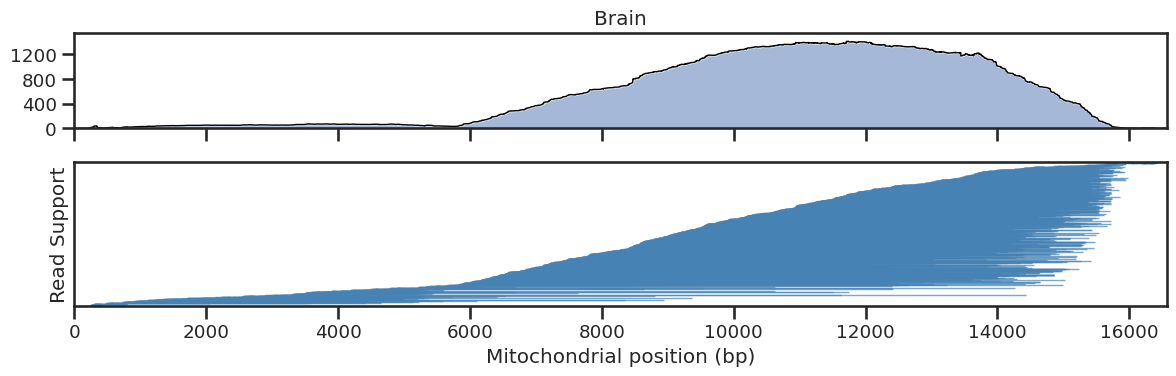

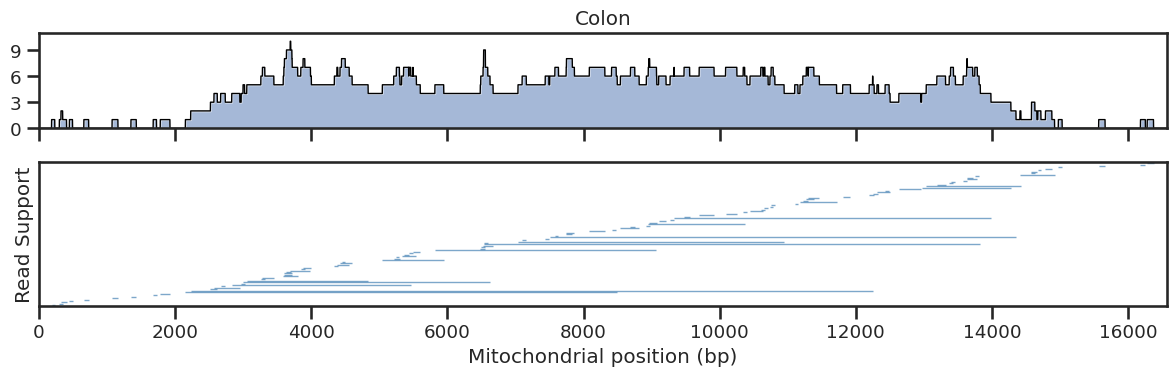

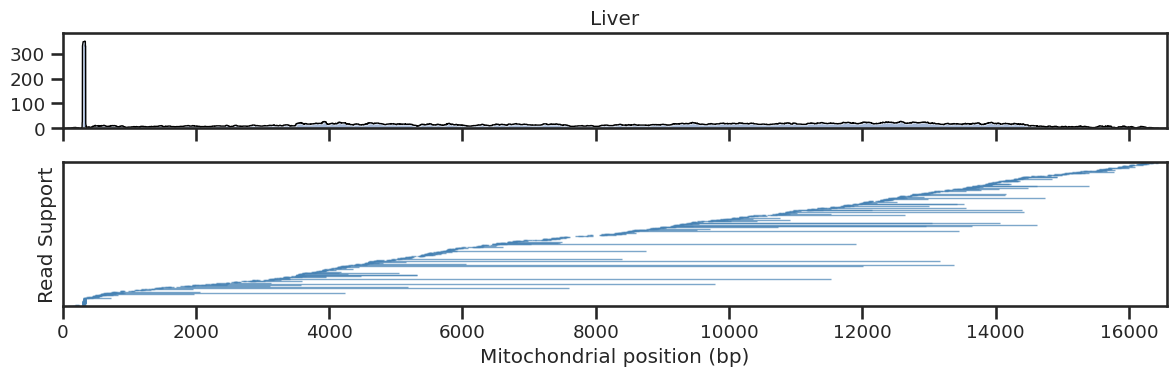

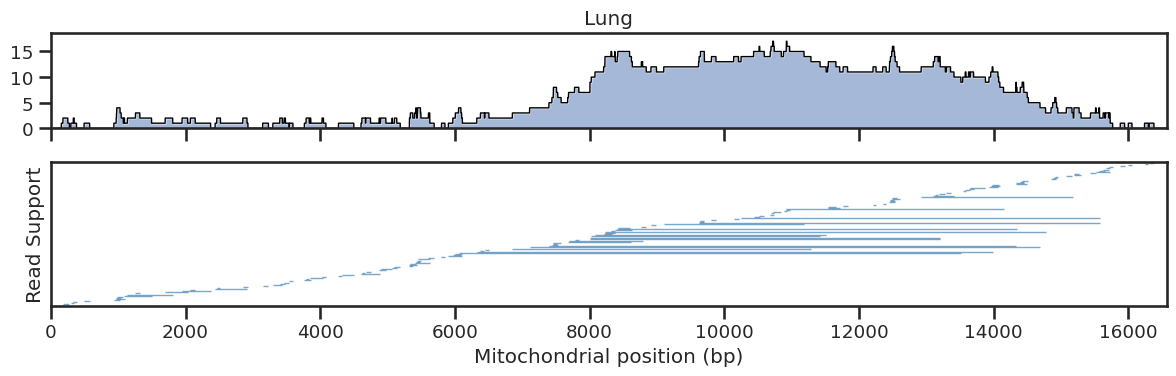

In [6]:
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

df = comb_del_df.copy().sort_values('Start')

mt_len = 16569

df["y"] = df.groupby("Tissue").cumcount()

for sample, sdf in df.groupby("Tissue"):

    fig, (ax_cov, ax_bar) = plt.subplots(
        2, 1,
        figsize=(12, 4),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1.5]}
    )

    coverage = np.zeros(mt_len, dtype=int)

    for _, row in sdf.iterrows():
        coverage[row["Start"]:row["End"]] += row["read_support"]

    ax_cov.plot(coverage, color="black", linewidth=1)
    ax_cov.fill_between(range(mt_len), coverage, alpha=0.5)
    ax_cov.set_ylim(0, max(coverage)+ max(coverage)*0.1)
    ax_cov.set_ylabel("")
    ax_cov.set_title(sample)
    ax_cov.yaxis.set_major_locator(plt.MaxNLocator(4))


    for _, row in sdf.iterrows():
        ax_bar.hlines(
            y=row["y"],
            xmin=row["Start"],
            xmax=row["End"],
            linewidth=1,
            alpha=0.7,
            color="steelblue"
        )

    ax_bar.set_xlim(0, mt_len)
    ax_bar.set_ylim(-0.5, sdf["y"].max() + 0.5)
    ax_bar.set_xlabel("Mitochondrial position (bp)")
    ax_bar.set_yticks([])
    ax_bar.set_ylabel("Read Support")

    plt.tight_layout()
    plt.savefig(f"plots/fig5-deletion_spanning_region_{sample}.pdf", dpi=300)
    plt.show()


In [7]:
crd = comb_del_df[
    (comb_del_df['Start'].isin(range(0,576))) | (comb_del_df['Start'].isin(range(16024,16569))) | (comb_del_df['End'].isin(range(0,576))) | (comb_del_df['End'].isin(range(16024,16569))) 
      ].groupby('Sample')['read_support'].sum().reset_index()
crd2 = comb_del_df[
    (comb_del_df['Start'].isin(range(287,307))) | (comb_del_df['Start'].isin(range(336,356))) | (comb_del_df['End'].isin(range(287,307))) | (comb_del_df['End'].isin(range(336,356))) 
      ].groupby('Sample')['read_support'].sum().reset_index()
common_del = comb_del_df[((comb_del_df['Start'].isin(range(8460,8480))) & (comb_del_df['End'].isin(range(13430,13455)))) | ((comb_del_df['End'].isin(range(8460,8480))) & (comb_del_df['Start'].isin(range(13430,13455))))].groupby('Sample')['read_support'].sum().reset_index()
major_arc_del = comb_del_df[(comb_del_df['Start'].isin(range(5576,15976))) & (comb_del_df['End'].isin(range(5576,15976))) & (comb_del_df['Size'] >= 50)].groupby('Sample')['read_support'].sum().reset_index()
minor_arc_del = comb_del_df[(comb_del_df['Start'].isin(range(0,5576))) & (comb_del_df['End'].isin(range(0,5576))) & (comb_del_df['Size'] > 300)].groupby('Sample')['read_support'].sum().reset_index()


crd = crd.set_index(['Sample']).reindex(comb_del_df['Sample'].unique()).fillna(0).reset_index()
crd[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = crd['Sample'].str.split('-', expand=True)
crd['Donor_Tissue'] = crd['Donor'] + "-" + crd['Tissue']
crd = pd.merge(crd, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
crd['per_mtdna'] = crd['read_support'] / crd['Mito_Read_Count']
crd

crd2 = crd2.set_index(['Sample']).reindex(comb_del_df['Sample'].unique()).fillna(0).reset_index()
crd2[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = crd2['Sample'].str.split('-', expand=True)
crd2['Donor_Tissue'] = crd2['Donor'] + "-" + crd2['Tissue']
crd2 = pd.merge(crd2, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
crd2['per_mtdna'] = crd2['read_support'] / crd2['Mito_Read_Count']
crd2

major_arc_del = major_arc_del.set_index(['Sample']).reindex(comb_del_df['Sample'].unique()).fillna(0).reset_index()
major_arc_del[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = major_arc_del['Sample'].str.split('-', expand=True)
major_arc_del['Donor_Tissue'] = major_arc_del['Donor'] + "-" + major_arc_del['Tissue']
major_arc_del = pd.merge(major_arc_del, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
major_arc_del['per_mtdna'] = major_arc_del['read_support'] / major_arc_del['Mito_Read_Count']
major_arc_del

minor_arc_del = minor_arc_del.set_index(['Sample']).reindex(comb_del_df['Sample'].unique()).fillna(0).reset_index()
minor_arc_del[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = minor_arc_del['Sample'].str.split('-', expand=True)
minor_arc_del['Donor_Tissue'] = minor_arc_del['Donor'] + "-" + minor_arc_del['Tissue']
minor_arc_del = pd.merge(minor_arc_del, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
minor_arc_del['per_mtdna'] = minor_arc_del['read_support'] / minor_arc_del['Mito_Read_Count']
minor_arc_del

common_del = common_del.set_index(['Sample']).reindex(comb_del_df['Sample'].unique()).fillna(0).reset_index()
common_del[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = common_del['Sample'].str.split('-', expand=True)
common_del['Donor_Tissue'] = common_del['Donor'] + "-" + common_del['Tissue']
common_del = pd.merge(common_del, df[['Sample', 'Mito_Read_Count']], on = 'Sample')
common_del['per_mtdna'] = common_del['read_support'] / common_del['Mito_Read_Count']
common_del


,Sample,read_support,Donor,Tissue,Seq_Tech,Center,Donor_Tissue,Mito_Read_Count,per_mtdna
0,ST001-1A_LIVER-pacbio-bcm,0.0,ST001,1A_LIVER,pacbio,bcm,ST001-1A_LIVER,13882,0.000000
1,ST001-1A_LIVER-pacbio-bcm,0.0,ST001,1A_LIVER,pacbio,bcm,ST001-1A_LIVER,13882,0.000000
2,ST001-1A_LIVER-pacbio-bcm,0.0,ST001,1A_LIVER,pacbio,bcm,ST001-1A_LIVER,13882,0.000000
3,ST001-1A_LIVER-pacbio-bcm,0.0,ST001,1A_LIVER,pacbio,bcm,ST001-1A_LIVER,13882,0.000000
4,ST001-1A_LIVER-pacbio-bcm,0.0,ST001,1A_LIVER,pacbio,bcm,ST001-1A_LIVER,13882,0.000000
...,...,...,...,...,...,...,...,...,...
3961,ST004-1Q_BRAIN-pacbio-washu,1.0,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN,28633,0.000035
3962,ST004-1Q_BRAIN-pacbio-washu,1.0,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN,28633,0.000035
3963,ST004-1Q_BRAIN-pacbio-washu,1.0,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN,28633,0.000035
3964,ST004-1Q_BRAIN-pacbio-washu,1.0,ST004,1Q_BRAIN,pacbio,washu,ST004-1Q_BRAIN,28633,0.000035


In [8]:
crd2.drop_duplicates().sort_values('read_support').groupby('Donor_Tissue')['per_mtdna'].mean()

Donor_Tissue
ST001-1A_LIVER    0.001779
ST001-1D_LUNG     0.000039
ST002-1D_LUNG     0.000000
ST002-1G_COLON    0.000016
ST003-1Q_BRAIN    0.000111
ST004-1Q_BRAIN    0.000103
Name: per_mtdna, dtype: float64

['ST001-1A_LIVER', 'ST001-1D_LUNG', 'ST002-1D_LUNG', 'ST002-1G_COLON', 'ST003-1Q_BRAIN', 'ST004-1Q_BRAIN']


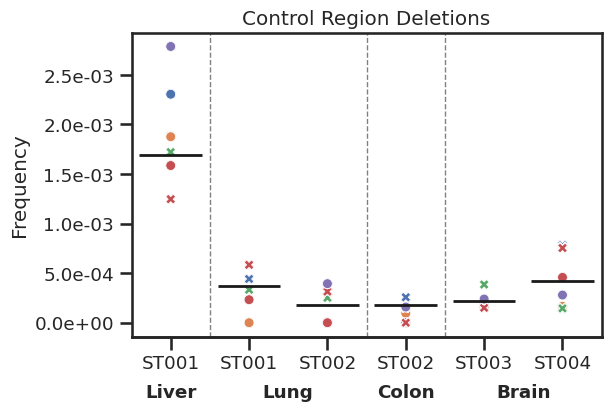

['ST001-1A_LIVER', 'ST001-1D_LUNG', 'ST002-1D_LUNG', 'ST002-1G_COLON', 'ST003-1Q_BRAIN', 'ST004-1Q_BRAIN']


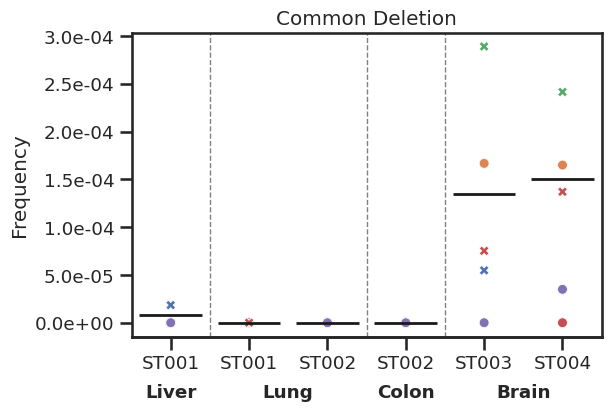

['ST001-1A_LIVER', 'ST001-1D_LUNG', 'ST002-1D_LUNG', 'ST002-1G_COLON', 'ST003-1Q_BRAIN', 'ST004-1Q_BRAIN']


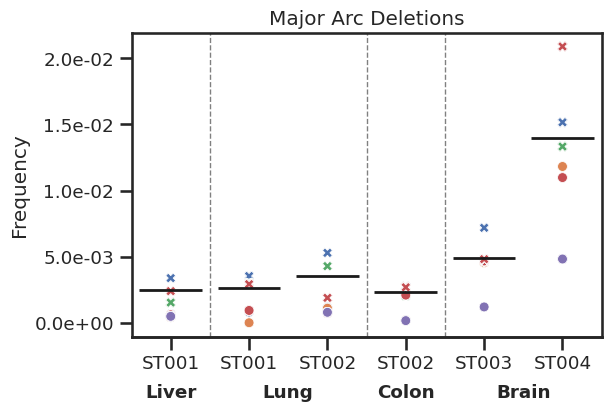

['ST001-1A_LIVER', 'ST001-1D_LUNG', 'ST002-1D_LUNG', 'ST002-1G_COLON', 'ST003-1Q_BRAIN', 'ST004-1Q_BRAIN']


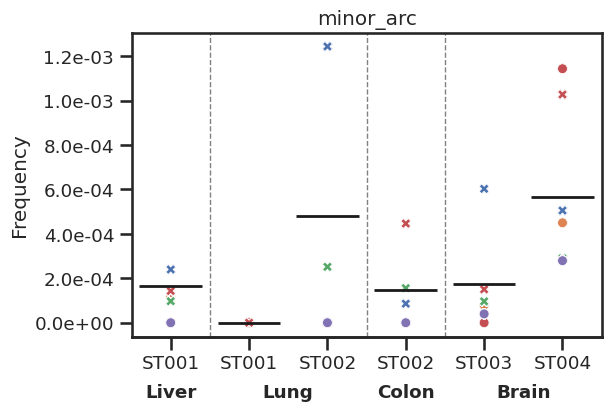

In [9]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

for plot_name, plot_type in zip(['Control Region Deletions', 'Common Deletion', 'Major Arc Deletions', 'minor_arc' ], [crd, common_del, major_arc_del, minor_arc_del]):

    fig, ax = plt.subplots(layout='constrained', figsize=(6, 4))

    sns.scatterplot(
        data=plot_type,
        x="Donor_Tissue",
        y="per_mtdna",
        hue="Center",
        style="Seq_Tech",
        s=50,
        legend=False,
        ax=ax
        )

    sns.boxplot(showmeans=True,
                meanline=True,
                meanprops={'color': 'k', 'ls': '-', 'lw': 2},
                medianprops={'visible': False},
                whiskerprops={'visible': False},
                zorder=10,
                x="Donor_Tissue",
                y="per_mtdna",
                data=plot_type,
                showfliers=False,
                showbox=False,
                showcaps=False,
                ax=ax)
    #plt.xticks(rotation=90)
    #plt.ylabel("Frequency")
    #plt.xlabel("")

    # Get original tick labels
    ticks = ax.get_xticklabels()
    labels = [t.get_text() for t in ticks]
    donors  = [l.split("-")[0] for l in labels]  
    tissues = ['\n\n' + l.split("-")[1].split("_")[1] for l in labels]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(donors, rotation=0)
    ax.set_ylabel("Frequency")
    ax.set_xlabel("")
    ax.set_title(plot_name)


    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks([0,1.5,3,4.5], labels=['\n\nLiver', '\n\nLung', '\n\nColon', '\n\nBrain'])
    sec.tick_params('x', length=0)

    for tick in sec.get_xticklabels():
        tick.set_fontweight("bold")
        #tick.set_fontsize(14)

    midpoints = [0.5,2.5,3.5]
    for x in midpoints:
        ax.axvline(x=x,color="gray",linestyle="--",linewidth=1,alpha=1,zorder=0)

   # plt.ylim(0,0.025)
    print(labels)

    import matplotlib.ticker as mtick
    formatter = mtick.FormatStrFormatter('%.1e') # '%.2e' formats to scientific notation with 2 decimal places
    ax.yaxis.set_major_formatter(formatter)

    plt.savefig(f"plots/fig5-deletion_freq_{plot_name}.pdf", dpi=300)
    plt.show()




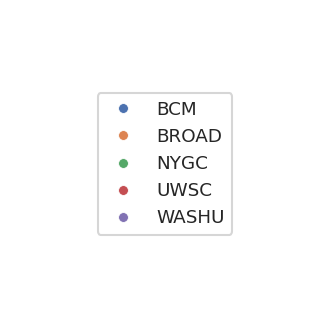

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(
    data=crd,
    x="Donor_Tissue",
    y="per_mtdna",
    hue="Center",
    style="Seq_Tech",
    s=50,
    legend=True,
    ax=ax
)

# Get legend safely
legend = ax.get_legend()

handles = legend.legend_handles if hasattr(legend, "legend_handles") else legend.legendHandles
labels = [t.get_text() if t.get_text() in ['Center', 'Seq_Tech']
           else 'PacBio' if t.get_text() == 'pacbio'
           else 'ONT' if  t.get_text() == 'ont'
           else t.get_text().upper() 
           for t in legend.get_texts() ]
title = legend.get_title().get_text()


# Clear axes AFTER grabbing legend info
ax.clear()
ax.set_axis_off()

leg = ax.legend(
    handles[1:6],
    labels[1:6],
    title=title,
    loc="center",
)

plt.savefig(
    "plots/fig5-deletion_freq_legend_center.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# leg = ax.legend(
#     handles[7:],
#     labels[7:],
#     title=title,
#     loc="center",
# )

# plt.savefig(
#     "plots/fig5-deletion_freq_legend_tech.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.show()




In [11]:
counts = comb_del_df.groupby('Sample').size().reset_index(name="Del_Count")
counts = pd.merge(counts, df[['Sample', 'Mito_Read_Count']], on='Sample')
counts['norm_count'] = counts['Del_Count'] / counts['Mito_Read_Count']
counts[['Donor', 'Tissue', 'Seq_Tech', 'Center']] = counts['Sample'].str.split('-', expand=True)
counts = counts.sort_values(['Donor', 'Tissue', 'Center'])
counts['Age'] = np.where(counts['Donor'].isin(['ST001', 'ST003']), 'Young', 'Old')
counts['Donor_Tissue'] = counts['Donor'] + "_" + counts['Tissue']

counts

,Sample,Del_Count,Mito_Read_Count,norm_count,Donor,Tissue,Seq_Tech,Center,Age,Donor_Tissue
0,ST001-1A_LIVER-ont-bcm,310,54220,0.005717,ST001,1A_LIVER,ont,bcm,Young,ST001_1A_LIVER
1,ST001-1A_LIVER-ont-bcm,310,54220,0.005717,ST001,1A_LIVER,ont,bcm,Young,ST001_1A_LIVER
2,ST001-1A_LIVER-ont-bcm,310,54220,0.005717,ST001,1A_LIVER,ont,bcm,Young,ST001_1A_LIVER
3,ST001-1A_LIVER-ont-bcm,310,54220,0.005717,ST001,1A_LIVER,ont,bcm,Young,ST001_1A_LIVER
4,ST001-1A_LIVER-ont-bcm,310,54220,0.005717,ST001,1A_LIVER,ont,bcm,Young,ST001_1A_LIVER
...,...,...,...,...,...,...,...,...,...,...
3961,ST004-1Q_BRAIN-pacbio-washu,154,28633,0.005378,ST004,1Q_BRAIN,pacbio,washu,Old,ST004_1Q_BRAIN
3962,ST004-1Q_BRAIN-pacbio-washu,154,28633,0.005378,ST004,1Q_BRAIN,pacbio,washu,Old,ST004_1Q_BRAIN
3963,ST004-1Q_BRAIN-pacbio-washu,154,28633,0.005378,ST004,1Q_BRAIN,pacbio,washu,Old,ST004_1Q_BRAIN
3964,ST004-1Q_BRAIN-pacbio-washu,154,28633,0.005378,ST004,1Q_BRAIN,pacbio,washu,Old,ST004_1Q_BRAIN


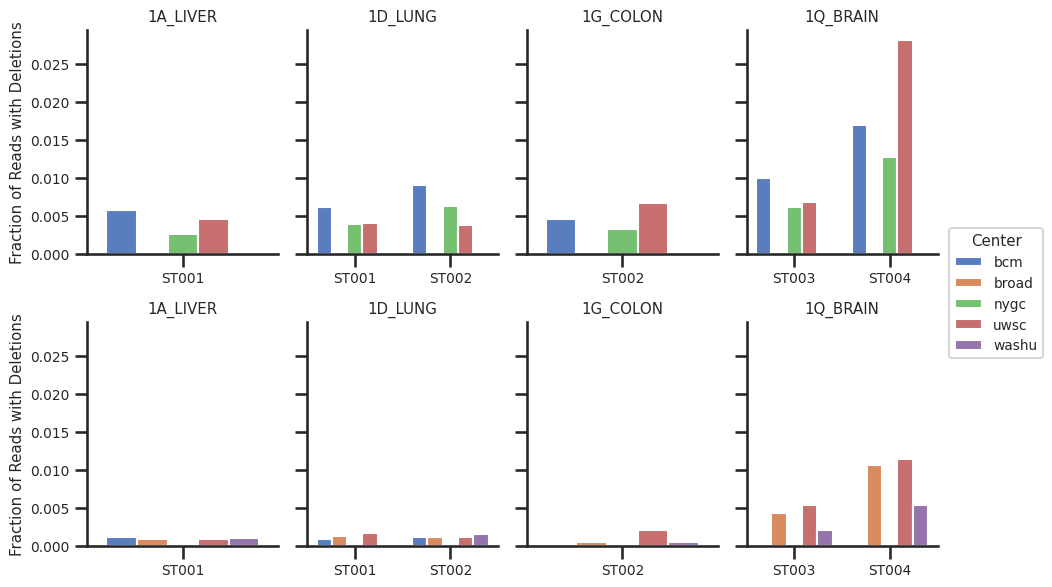

In [12]:

sns.set_theme(style="ticks", context="talk", font_scale=0.6)

g = sns.catplot(
    data=counts,
    x="Donor",
    y="norm_count",
    col="Tissue",
    row="Seq_Tech",
    hue="Center",
    kind="bar",
    height=3,
    aspect=0.8,
    palette="muted",
    legend_out=False,
    sharex=False,
    sharey=True
)
sns.move_legend(g, "center right", bbox_to_anchor=(1.1,0.5)) 
g.set_titles("{col_name}")
g.set_axis_labels("", "Fraction of Reads with Deletions")
plt.tight_layout()
plt.show()

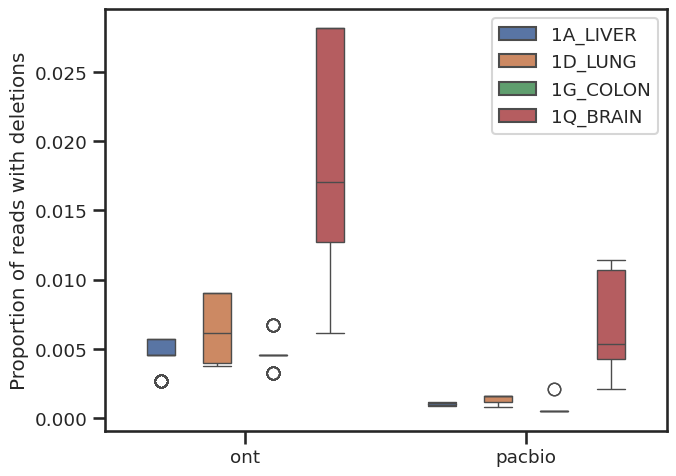

In [13]:

sns.set_theme(style="ticks", context="talk", font_scale=0.8)

plt.figure(figsize=(7,5))
g = sns.boxplot(
    data=counts,
    hue="Tissue",
    y="norm_count",
    x="Seq_Tech",
    widths=0.1
)
plt.legend(bbox_to_anchor=(1, 1), loc='best')
plt.ylabel("Proportion of reads with deletions")
plt.xlabel("")
plt.tight_layout()
#plt.yscale('log')
plt.show()

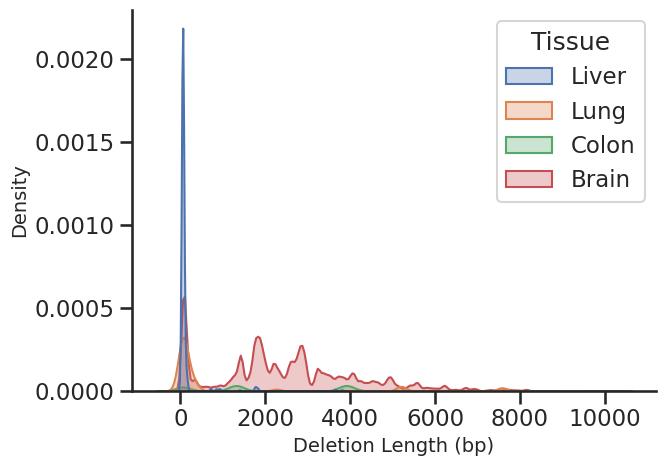

In [14]:

sns.set_theme(style="ticks", context="talk", font_scale=1)
plt.figure(figsize=(7,5))

sns.kdeplot(
    data=comb_del_df[comb_del_df['Seq_Tech'] == 'pacbio'],
    x="Size",
    weights="per_mtdna", 
    fill=True,
    hue="Tissue",
    alpha=0.3,
 #   bins=50,
   # palette='Set2',
    bw_adjust=0.1

)

plt.xlabel("Deletion Length (bp)", fontsize=14)
plt.ylabel("Density", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


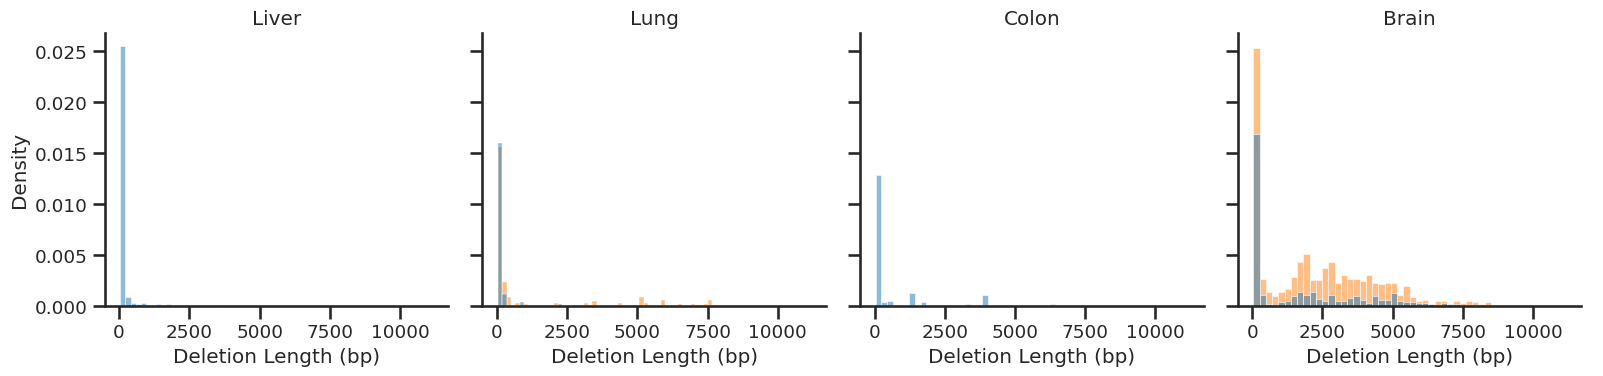

In [15]:
sns.set_theme(style="ticks", context="talk", font_scale=0.8)

# Create a facet grid: one column per donor
g = sns.FacetGrid(comb_del_df, col="Tissue", col_wrap=4, height=4, sharex=True, sharey=True)

# Map your KDE to each facet
g.map_dataframe(
    sns.histplot,
    x="Size",
    weights="per_mtdna",
    hue="Age",
    fill=True,
    bins=50,
   # alpha=0.5,
   #bw_adjust=0.1,
    palette="tab10",
    legend=True
)

# Adjust legend and labels
g.set_axis_labels("Deletion Length (bp)", "Density")
g.set_titles(col_template="{col_name}")  # show donor name
g.add_legend(title="")
#sns.despine()
plt.tight_layout()
plt.show()


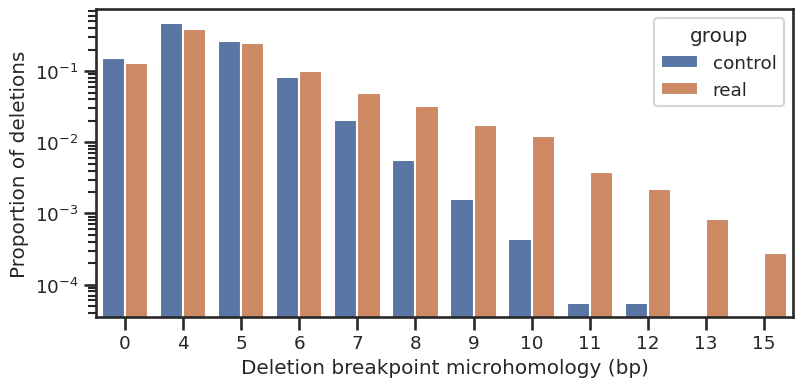

In [16]:
hom = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/del_flank_all.tsv', sep='\t', skiprows=1, header=None, keep_default_na=False)
hom.columns = ['id_l', 'id_r', 'length', ]
hom['group'] = 'real'

hom_control = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/del_flanks_control_all.tsv', sep='\t', skiprows=1, header=None, keep_default_na=False)
hom_control.columns = ['id_l', 'id_r', 'length']
hom_control['group'] = 'control'

df = pd.concat([hom, hom_control])


df['length'] = np.where(df['length'] == 'NA', '0', df['length'])
df['length'] = df['length'].astype(int)

df

prop_df = df.groupby('group')['length'].value_counts(normalize=True).rename('proportion').reset_index()

prop_df

sns.set_theme(style="ticks", context="talk", font_scale=0.8)
plt.figure(figsize=(9,4))

sns.barplot(data=prop_df.sort_values("length"), x="length", y='proportion', hue='group')
plt.yscale('log')
plt.xlabel('Deletion breakpoint microhomology (bp)')
plt.ylabel('Proportion of deletions')
plt.savefig(f"plots/fig5-deletion_homology.pdf", dpi=300,  bbox_inches='tight')
plt.show()

In [17]:
from scipy.stats import mannwhitneyu

df2 = df.dropna()

real = df2[df2.group == "real"]["length"]
offset = df2[df2.group == "control"]["length"]

stat, p = mannwhitneyu(real, offset, alternative="greater")

print(p)


6.984412179104161e-43


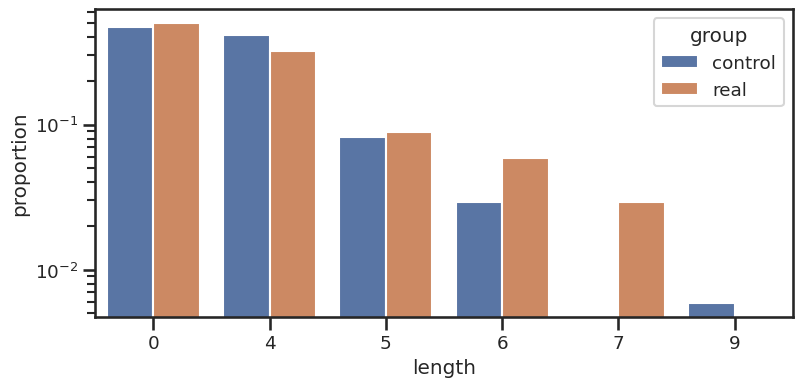

In [18]:
hom = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/numt_flanks.tsv', sep='\t', skiprows=1, header=None, keep_default_na=False)
hom.columns = ['id_l', 'id_r', 'length', ]
hom['group'] = 'real'

hom_control = pd.read_csv('/net/nwgc/vol1/home/czaka/analysis/mitoscope/smaht/analysis/homology_analysis/numt_flanks_control.tsv', sep='\t', skiprows=1, header=None, keep_default_na=False)
hom_control.columns = ['id_l', 'id_r', 'length']
hom_control['group'] = 'control'

df = pd.concat([hom, hom_control])


df['length'] = np.where(df['length'] == 'NA', '0', df['length'])
df['length'] = df['length'].astype(int)

df

prop_df = df.groupby('group')['length'].value_counts(normalize=True).rename('proportion').reset_index()

prop_df

sns.set_theme(style="ticks", context="talk", font_scale=0.8)
plt.figure(figsize=(9,4))

sns.barplot(data=prop_df.sort_values("length"), x="length", y='proportion', hue='group')
plt.yscale('log')
plt.show()

In [19]:
from scipy.stats import mannwhitneyu

df2 = df.dropna()

real = df2[df2.group == "real"]["length"]
offset = df2[df2.group == "control"]["length"]

stat, p = mannwhitneyu(real, offset, alternative="greater")

print(p)


0.4617202438018292
